In [1]:
import pandas as pd
from rich import print

In [2]:
data = pd.read_csv(r"data\SPECS\labels\processed\global_mapped_cleaned_with_ahiremapped.csv",index_col=0)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Respondent                50000 non-null  int64  
 1   Country                   50000 non-null  object 
 2   gender                    50000 non-null  object 
 3   age_group                 50000 non-null  object 
 4   age_group_2               50000 non-null  object 
 5   nationality               50000 non-null  object 
 6   city_living               50000 non-null  object 
 7   city_living_length        50000 non-null  object 
 8   ahi                       50000 non-null  object 
 9   ahi_2                     50000 non-null  object 
 10  ahi_3                     50000 non-null  object 
 11  num_household             50000 non-null  int64  
 12  education_level           50000 non-null  object 
 13  race_ethnicity            50000 non-null  object 
 14  extraversio

In [ ]:

respondents = data.drop_duplicates(subset="Respondent")
#Features that we are interessed to build the personas from:
    #Country
    #Age Group
    #Gender
    #Identified Nationality
    #Country you live in
    #AHI - bottom - middle - upper
    #Education
    #Ethnicity

respondents




,Respondent,Country,gender,age_group,age_group_2,nationality,city_living,city_living_length,ahi,ahi_2,...,neuroticism_median,neuroticism_q3_q1,openness_median,openness_q3_q1,Question,Left_image,Right_image,ahi_3_remapped,education_level_remapped,Score
0,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,203,44,middle,college_vocational_diploma,left
50,5,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$25,000 - SGD$44,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,326,78,bottom,primary_secondary,right
100,6,Singapore,female,30-39,21-39,Singapore,Singapore,Above 5 years,"SGD$10,000 - SGD$24,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,58,137,bottom,postgraduate,right
150,7,Singapore,male,Above 50,40+,Singapore,Singapore,Above 5 years,"SGD$180,000 - SGD$999,999","SGD$100,000 - SGD$999,999",...,1,1.0,0,0.0,safe,370,323,upper,undergraduate,equal
200,8,Singapore,female,30-39,21-39,Singapore,Singapore,Above 5 years,"SGD$25,000 - SGD$44,999","SGD$0 - SGD$99,999",...,1,1.0,1,NaN,safe,378,228,bottom,undergraduate,right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49750,5399,USA,male,21-29,21-39,United States,17.0,3-5 years,"USD$25,000 - USD$34,999","USD$0 - USD$99,999",...,1,1.0,1,1.0,safe,77,295,bottom,postgraduate,left
49800,5400,USA,female,21-29,21-39,United States,17.0,Above 5 years,"USD$200,000 - USD$999,999","USD$100,000 - USD$999,999",...,1,1.0,1,NaN,safe,163,242,upper,college_vocational_diploma,left
49850,5409,USA,male,21-29,21-39,United States,17.0,Above 5 years,"USD$75,000 - USD$99,999","USD$0 - USD$99,999",...,0,0.0,1,NaN,safe,81,95,middle,undergraduate,right
49900,5419,USA,male,21-29,21-39,United States,17.0,1-3 years,"USD$50,000 - USD$74,999","USD$0 - USD$99,999",...,1,1.0,1,1.0,safe,53,377,middle,undergraduate,right


GENDER

In [4]:
print(data.groupby("gender")["Respondent"].nunique().reset_index())

data.groupby(["Country", "gender"])["Respondent"].nunique().reset_index()

gender  Respondent
0  female         502
1    male         498

,Country,gender,Respondent
0,Chile,female,102
1,Chile,male,98
2,Netherlands,female,100
3,Netherlands,male,100
4,Nigeria,female,98
5,Nigeria,male,102
6,Singapore,female,102
7,Singapore,male,98
8,USA,female,100
9,USA,male,100


AGE GROUP

In [5]:
print(data.groupby("age_group")["Respondent"].nunique().reset_index())

data.groupby(["Country", "age_group"])["Respondent"].nunique().reset_index()

  age_group  Respondent
0     21-29         200
1     30-39         204
2     40-49         180
3  Above 50         416


,Country,age_group,Respondent
0,Chile,21-29,40
1,Chile,30-39,42
2,Chile,40-49,38
3,Chile,Above 50,80
4,Netherlands,21-29,32
5,Netherlands,30-39,34
6,Netherlands,40-49,32
7,Netherlands,Above 50,102
8,Nigeria,21-29,62
9,Nigeria,30-39,56


In [5]:

print(data.groupby("extraversion_median")["Respondent"].nunique().reset_index())
print(data.groupby("agreeableness_median")["Respondent"].nunique().reset_index())
print(data.groupby("conscientiousness_median")["Respondent"].nunique().reset_index())
print(data.groupby("neuroticism_median")["Respondent"].nunique().reset_index())
print(data.groupby("openness_median")["Respondent"].nunique().reset_index())

extraversion_median  Respondent
0                    0         360
1                    1         640

agreeableness_median  Respondent
0                     0         489
1                     1         511

conscientiousness_median  Respondent
0                         0         433
1                         1         567

neuroticism_median  Respondent
0                   0         344
1                   1         656

openness_median  Respondent
0                0         474
1                1         526

The SPECS study created 3 divisions (bottom,middle,upper) for the anual house income (AHI) collumn, using the following rules:<br>
    
        "20,400,000 CLP & below": "bottom",
        "20,400,001 CLP-60,400,000 CLP": "middle",
        "60,400,001 CLP & above": "upper",
        
        "29,999 euros & below": "bottom",
        "30,000 euros-81,999 euros": "middle",
        "82,000 euros & above": "upper",
        
        "2,000,000 NGN & below": "bottom",
        "2,000,001 NGN-4,000,000 NGN": "middle",
        "4,000,001 NGN & above": "upper",
        
        "SGD$0 - SGD$44,999": "bottom",
        "SGD$45,000 - SGD$99,999": "middle",
        "SGD$100,000 - SGD$999,999": "upper",
        
        "USD$0 - USD$49,999": "bottom",
        "USD$50,000 - USD$99,999": "middle",
        "USD$100,000 - USD$999,999": "upper",
        
        "Prefer not to answer": "Prefer not to answer",

In [6]:
print(data.groupby("ahi_3_remapped")["Respondent"].nunique().reset_index())

data.groupby(["Country", "ahi_3_remapped"])["Respondent"].nunique().reset_index()


         ahi_3_remapped  Respondent
0  Prefer not to answer          39
1                bottom         339
2                middle         327
3                 upper         295


,Country,ahi_3_remapped,Respondent
0,Chile,Prefer not to answer,12
1,Chile,bottom,119
2,Chile,middle,50
3,Chile,upper,19
4,Netherlands,Prefer not to answer,17
5,Netherlands,bottom,43
6,Netherlands,middle,101
7,Netherlands,upper,39
8,Nigeria,Prefer not to answer,6
9,Nigeria,bottom,66


EDUCATION LEVEL

In [7]:
data.groupby("education_level_remapped")["Respondent"].nunique().reset_index()

,education_level_remapped,Respondent
0,college_vocational_diploma,229
1,other,11
2,postgraduate,160
3,primary_secondary,220
4,undergraduate,380


Race and Ethinicity

In [25]:
data.groupby("race_ethnicity")["Respondent"].nunique().reset_index()

,race_ethnicity,Respondent
0,A race/ethnicity not listed here,69
1,Asian or Pacific Islander,231
2,Black or African American,184
3,Hispanic or Latino,166
4,Middle Eastern or North African,32
5,Native American or Alaska Native,5
6,White or Caucasian,313


In [26]:

data.groupby(["Country", "race_ethnicity"])["Respondent"].nunique().reset_index()

,Country,race_ethnicity,Respondent
0,Chile,A race/ethnicity not listed here,6
1,Chile,Black or African American,1
2,Chile,Hispanic or Latino,145
3,Chile,Middle Eastern or North African,1
4,Chile,Native American or Alaska Native,1
5,Chile,White or Caucasian,46
6,Netherlands,A race/ethnicity not listed here,24
7,Netherlands,Asian or Pacific Islander,4
8,Netherlands,Black or African American,5
9,Netherlands,Hispanic or Latino,4


Personalities:<br>
Extraversion
Agreeableness:
Conscientiousness
Neuroticism
Openness

Possible values: 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0<br>
They were calculated using the following formula: 
trait = (positive_question + (6 - negative_question)) / 2


In [9]:
random_respondent = respondents.sample(1).iloc[0]

traits = [
    "extraversion",
    "agreeableness",
    "conscientiousness",
    "neuroticism",
    "openness"
]

for trait in traits:
    score = random_respondent[trait]
    median = random_respondent[f"{trait}_median"]
    
    print(f"{trait.capitalize()}: {score} | Median: {median}")

Extraversion: 1.5 | Median: 0
Agreeableness: 4.0 | Median: 1
Conscientiousness: 4.0 | Median: 1
Neuroticism: 2.0 | Median: 0
Openness: 4.5 | Median: 1


In [16]:
#df.drop(df.index[df['estado_fisico'] == 'nao Informado'], inplace=True)
data_safe = data[data.Question == 'safe']
print(data_safe.Respondent.nunique())

data_safe

1000


,Respondent,Country,gender,age_group,age_group_2,nationality,city_living,city_living_length,ahi,ahi_2,...,neuroticism_median,neuroticism_q3_q1,openness_median,openness_q3_q1,Question,Left_image,Right_image,ahi_3_remapped,education_level_remapped,Score
0,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,203,44,middle,college_vocational_diploma,left
1,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,305,382,middle,college_vocational_diploma,left
2,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,276,69,middle,college_vocational_diploma,left
3,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,45,278,middle,college_vocational_diploma,left
4,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,380,305,middle,college_vocational_diploma,right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49950,5459,USA,female,21-29,21-39,United States,17.0,Above 5 years,"USD$0 - USD$24,999","USD$0 - USD$99,999",...,1,1.0,0,0.0,safe,36,185,bottom,college_vocational_diploma,left
49951,5459,USA,female,21-29,21-39,United States,17.0,Above 5 years,"USD$0 - USD$24,999","USD$0 - USD$99,999",...,1,1.0,0,0.0,safe,351,90,bottom,college_vocational_diploma,right
49952,5459,USA,female,21-29,21-39,United States,17.0,Above 5 years,"USD$0 - USD$24,999","USD$0 - USD$99,999",...,1,1.0,0,0.0,safe,230,211,bottom,college_vocational_diploma,left
49953,5459,USA,female,21-29,21-39,United States,17.0,Above 5 years,"USD$0 - USD$24,999","USD$0 - USD$99,999",...,1,1.0,0,0.0,safe,380,251,bottom,college_vocational_diploma,left


Mean classifications per image: 25.00

Median classifications per image: 25.00

Minimum classifications for one image: 11

Maximum classifications for one image: 42

Least classified image(s):

92    11
Name: count, dtype: int64

Most classified image(s):

155    42
Name: count, dtype: int64

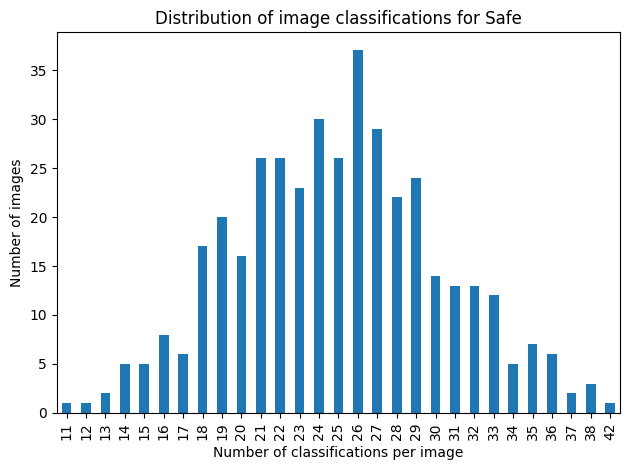

In [29]:
import matplotlib.pyplot as plt

# Combine all image appearances
image_counts = pd.concat([
    data_safe["Left_image"],
    data_safe["Right_image"]
]).value_counts().sort_index()


print(f"Mean classifications per image: {image_counts.mean():.2f}")
print(f"Median classifications per image: {image_counts.median():.2f}")
print(f"Minimum classifications for one image: {image_counts.min()}")
print(f"Maximum classifications for one image: {image_counts.max()}\n")
print("Least classified image(s):")
print(image_counts[image_counts == image_counts.min()])

print("\nMost classified image(s):")
print(image_counts[image_counts == image_counts.max()])

# Create bar graph
image_counts.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of classifications per image")
plt.ylabel("Number of images")
plt.title("Distribution of image classifications for Safe")

plt.tight_layout()
plt.show()

plt.show()

Mean classifications per image: 25.00
Median classifications per image: 25.00
Minimum classifications for one image: 11
Maximum classifications for one image: 42

Least classified image(s):
92    11
Name: count, dtype: int64

Most classified image(s):
155    42
Name: count, dtype: int64


In [27]:
data_safe_filtered = data_safe[
    (data_safe["race_ethnicity"] != "A race/ethnicity not listed here") &
    (data_safe["race_ethnicity"] != "Native American or Alaska Native") &
    (data_safe["education_level_remapped"] != "other") &
    (data_safe["ahi_3_remapped"] != "Prefer not to answer")
].copy()

print(f"Original respondents: {data_safe['Respondent'].nunique()}")
print(f"Filtered respondents: {data_safe_filtered['Respondent'].nunique()}")

print(f"\nOriginal rows: {len(data_safe)}")
print(f"Filtered rows: {len(data_safe_filtered)}")

data_safe_filtered

Original respondents: 1000

Filtered respondents: 890

Original rows: 5000

Filtered rows: 4450

,Respondent,Country,gender,age_group,age_group_2,nationality,city_living,city_living_length,ahi,ahi_2,...,neuroticism_median,neuroticism_q3_q1,openness_median,openness_q3_q1,Question,Left_image,Right_image,ahi_3_remapped,education_level_remapped,Score
0,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,203,44,middle,college_vocational_diploma,left
1,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,305,382,middle,college_vocational_diploma,left
2,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,276,69,middle,college_vocational_diploma,left
3,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,45,278,middle,college_vocational_diploma,left
4,4,Singapore,female,40-49,40+,Singapore,Singapore,Above 5 years,"SGD$82,000 - SGD$99,999","SGD$0 - SGD$99,999",...,1,1.0,0,0.0,safe,380,305,middle,college_vocational_diploma,right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49950,5459,USA,female,21-29,21-39,United States,17.0,Above 5 years,"USD$0 - USD$24,999","USD$0 - USD$99,999",...,1,1.0,0,0.0,safe,36,185,bottom,college_vocational_diploma,left
49951,5459,USA,female,21-29,21-39,United States,17.0,Above 5 years,"USD$0 - USD$24,999","USD$0 - USD$99,999",...,1,1.0,0,0.0,safe,351,90,bottom,college_vocational_diploma,right
49952,5459,USA,female,21-29,21-39,United States,17.0,Above 5 years,"USD$0 - USD$24,999","USD$0 - USD$99,999",...,1,1.0,0,0.0,safe,230,211,bottom,college_vocational_diploma,left
49953,5459,USA,female,21-29,21-39,United States,17.0,Above 5 years,"USD$0 - USD$24,999","USD$0 - USD$99,999",...,1,1.0,0,0.0,safe,380,251,bottom,college_vocational_diploma,left


Mean classifications per image: 22.25

Median classifications per image: 22.00

Minimum classifications for one image: 9

Maximum classifications for one image: 36

Least classified image(s):

92    9
Name: count, dtype: int64

Most classified image(s):

69    36
Name: count, dtype: int64

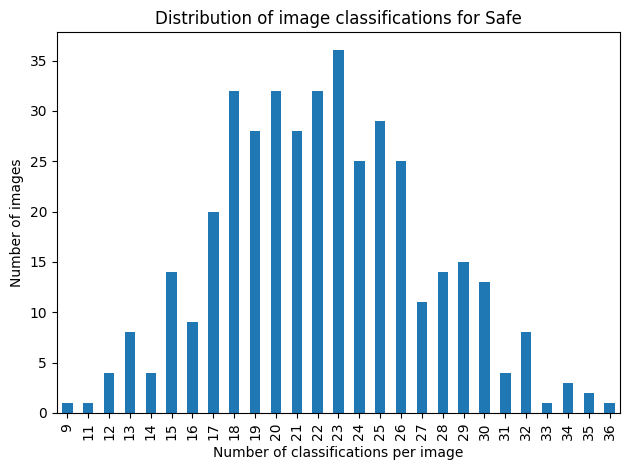

In [30]:

# Combine all image appearances
image_counts = pd.concat([
    data_safe_filtered["Left_image"],
    data_safe_filtered["Right_image"]
]).value_counts().sort_index()


print(f"Mean classifications per image: {image_counts.mean():.2f}")
print(f"Median classifications per image: {image_counts.median():.2f}")
print(f"Minimum classifications for one image: {image_counts.min()}")
print(f"Maximum classifications for one image: {image_counts.max()}\n")
print("Least classified image(s):")
print(image_counts[image_counts == image_counts.min()])

print("\nMost classified image(s):")
print(image_counts[image_counts == image_counts.max()])

# Create bar graph
image_counts.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of classifications per image")
plt.ylabel("Number of images")
plt.title("Distribution of image classifications for Safe")

plt.tight_layout()
plt.show()

plt.show()

In [1]:
from pathlib import Path
from PIL import Image
from collections import Counter

root = Path(r"data\SPECS\svi")

resolution_counts = Counter()

for image_path in root.rglob("*"):
    if image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}:
        try:
            with Image.open(image_path) as img:
                resolution_counts[img.size] += 1
        except Exception:
            pass

for (width, height), count in sorted(resolution_counts.items()):
    print(f"{width} x {height}: {count} images")

1067 x 1600: 1 images
1071 x 1600: 1 images
1600 x 1067: 1 images
1920 x 1080: 139 images
2048 x 1152: 10 images
2048 x 1536: 163 images
2048 x 2048: 7 images
2592 x 1936: 2 images
3072 x 1728: 71 images
3264 x 2448: 3 images
4032 x 3024: 2 images


| Variable | Category | Count |
|---|---|---:|
| **gender** | female | 502 |
| | male | 498 |
| **age_group** | 21-29 | 200 |
| | 30-39 | 204 |
| | 40-49 | 180 |
| | Above 50 | 416 |
| **ahi_3_remapped** | Prefer not to answer | 39 |
| | bottom | 339 |
| | middle | 327 |
| | upper | 297 |
| **education_level_remapped** | college_vocational_diploma | 229 |
| | other | 11 |
| | postgraduate | 160 |
| | primary_secondary | 220 |
| | undergraduate | 380 |
| **race_ethnicity** | Asian or Pacific Islander | 231 |
| | Black or African American | 184 |
| | Hispanic or Latino | 166 |
| | Middle Eastern or North African | 32 |
| | White or Caucasian | 313 |
| | Native American or Alaska Native | 5 |
| | A race/ethnicity not listed here | 69 |
| **extraversion_median** | 0 | 360 |
| | 1 | 640 |
| **agreeableness_median** | 0 | 489 |
| | 1 | 511 |
| **conscientiousness_median** | 0 | 433 |
| | 1 | 567 |
| **neuroticism_median** | 0 | 344 |
| | 1 | 656 |
| **openness_median** | 0 | 474 |
| | 1 | 526 |